In [4]:
import pandas as pd
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Task 1

In [5]:
housing = pd.read_csv("housing.csv")
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Task 2

### functions

In [6]:
def unique_vals(dataset, col: str):
    return dataset[col].unique()

In [19]:

def plot_histogram(dataset, column:str):
    plt.figure(figsize=(10, 6))
    plt.hist(dataset[column], bins=100, edgecolor='black')
    plt.xlabel(column)
    plt.ylabel("frequency")
    plt.title(f"Histogram of {column}")
    plt.show()

### Ans to the reasearch questions

In [9]:
print(unique_vals(housing, "ocean_proximity"))

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


In [10]:
housing.groupby(["latitude","longitude"]).ngroups
# Q1) so there are 12590 geographical units?

12590

In [11]:
#mean house value among all ocean proximities
housing["median_house_value"].mean()

np.float64(206855.81690891474)

In [12]:
#mean house value among different ocean proximities
housing.groupby("ocean_proximity")["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

In [13]:
housing.groupby("ocean_proximity")["median_house_value"].median()

ocean_proximity
<1H OCEAN     214850.0
INLAND        108500.0
ISLAND        414700.0
NEAR BAY      233800.0
NEAR OCEAN    229450.0
Name: median_house_value, dtype: float64

In [14]:
# mean values for the ocean proximity categories tell us the central value in the dataset --> can be influenced by extreme values

#median is the middle value in the dataset, after sorting the values,--> which is less affected by extreme values

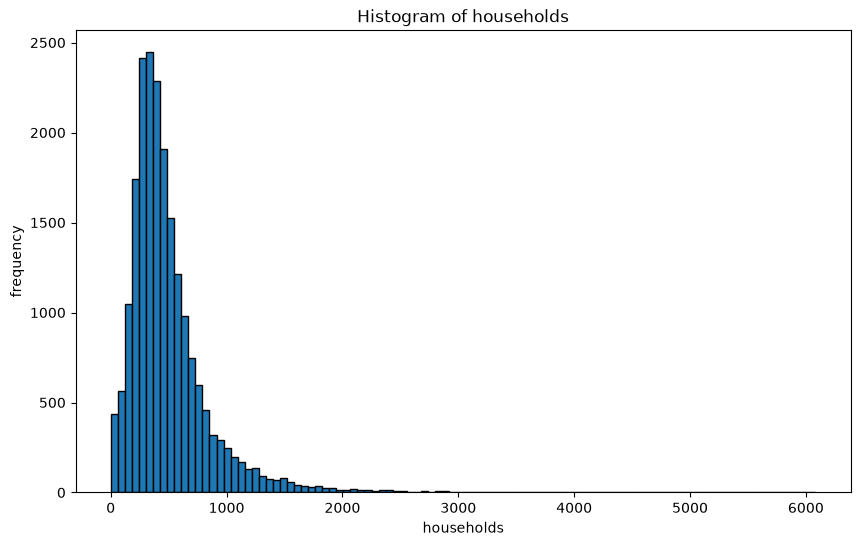

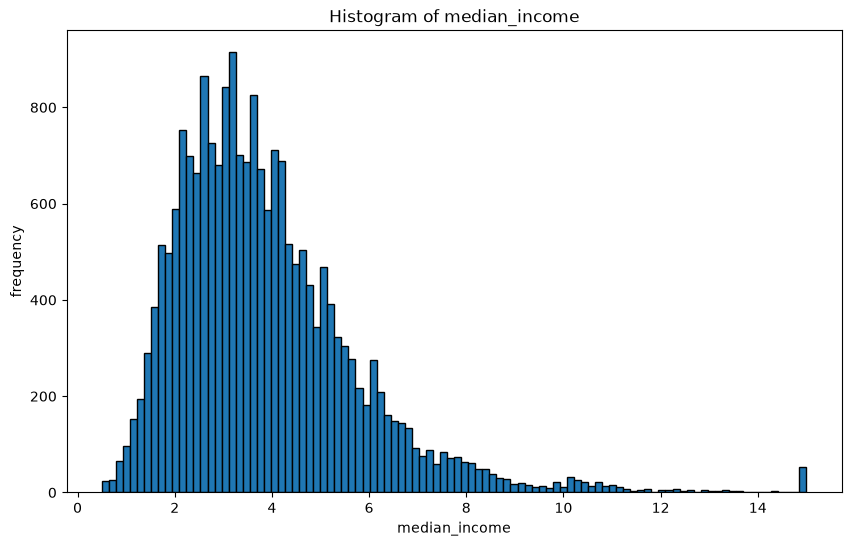

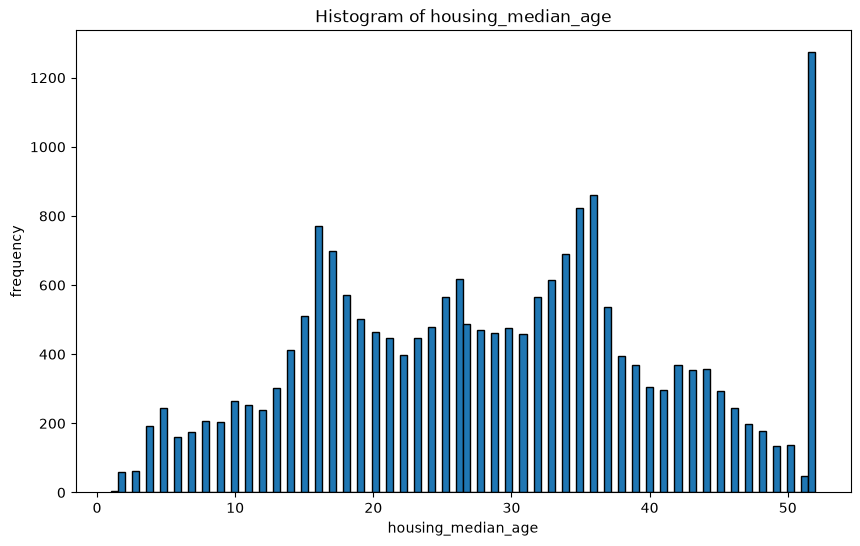

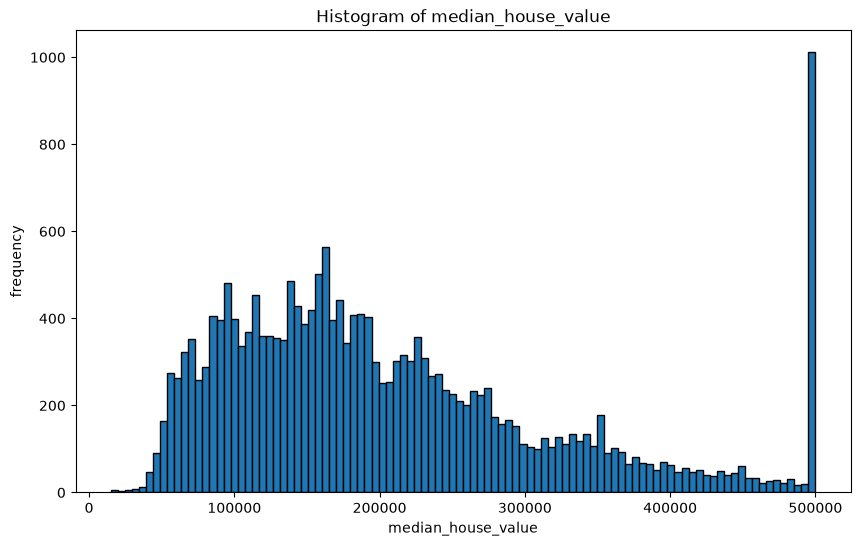

In [20]:
#plot histogram for different columns in the housing dataset
plot_histogram(housing, "households")
plot_histogram(housing, "median_income")
plot_histogram(housing, "housing_median_age")
plot_histogram(housing, "median_house_value")

### these histograms give us the distribution of the data across the specific collumns, to find the range, and other metrics quickly. we see a bit of normal distributed curves in the histograms, 
#### 1) The graph is normally distributed and left skewed, ,
#### 2) can spot some clear outliers
#### 3) The spike in frequency for the median house value and hosuing meadian age at the end can be interpreted as the people who are old have got the most valued house, which means the dataset has a lot of records that are at the maximum
#### 4) A significant portion of the data is clustered near the maximum value, which means a lot of properties are significantly costly
#### was this possible to identify since the median values were used in the dataset?




In [ ]:
n which category are the most expensive and the largest houses typically located? In which
category are the least expensive and smallest houses typically located?
8. What can you tell about the quality of houses in each “Ocean_proximity” category? (e.g., the age
of the houses, the number of rooms)
9. What can you tell about the demographic living in each “Ocean_proximity” category? (e.g.,
population, households, median income)
10. Are there any other interesting observations and questions you can come up with regarding this
dataset?

In [22]:
housing.groupby("ocean_proximity")[["median_house_value", "total_rooms"]].max()

,median_house_value,total_rooms
ocean_proximity,,
<1H OCEAN,500001.0,37937.0
INLAND,500001.0,39320.0
ISLAND,450000.0,2359.0
NEAR BAY,500001.0,18634.0
NEAR OCEAN,500001.0,30405.0


In [23]:
housing.groupby("ocean_proximity")[["median_house_value", "total_rooms"]].min()

,median_house_value,total_rooms
ocean_proximity,,
<1H OCEAN,17500.0,11.0
INLAND,14999.0,2.0
ISLAND,287500.0,716.0
NEAR BAY,22500.0,8.0
NEAR OCEAN,22500.0,15.0


In [41]:
summary_quality = housing.groupby("ocean_proximity")[["housing_median_age", "total_rooms", "median_house_value"]].describe()
print(summary_quality.to_string())

                housing_median_age                                                     total_rooms                                                                     median_house_value                                                                                
                             count       mean        std   min   25%   50%   75%   max       count         mean          std    min      25%     50%      75%      max              count           mean            std       min       25%       50%       75%       max
ocean_proximity                                                                                                                                                                                                                                                          
<1H OCEAN                   9136.0  29.279225  11.644453   2.0  20.0  30.0  37.0  52.0      9136.0  2628.343586  2160.463696   11.0  1464.00  2108.0  3141.00  37937.0             9136.0  240084.285464  

In [37]:
housing.groupby("ocean_proximity")[["housing_median_age", "total_rooms", "median_house_value"]].median()


,housing_median_age,total_rooms,median_house_value
ocean_proximity,,,
<1H OCEAN,30.0,2108.0,214850.0
INLAND,23.0,2131.0,108500.0
ISLAND,52.0,1675.0,414700.0
NEAR BAY,39.0,2083.0,233800.0
NEAR OCEAN,29.0,2195.0,229450.0


#### overall, the houses in the "island" category are the most expensive and have the oldest homes, while the houses in the "INLAND" category are the least expensive and have the smallest number of rooms.and are relatively newer

In [42]:
summary_demographics = housing.groupby("ocean_proximity")[["population","households","median_income"]].describe()
print(summary_demographics.to_string())

                population                                                                   households                                                              median_income                                                                  
                     count         mean          std    min     25%     50%     75%      max      count        mean         std    min    25%    50%     75%     max         count      mean       std     min       25%      50%       75%      max
ocean_proximity                                                                                                                                                                                                                                     
<1H OCEAN           9136.0  1520.290499  1185.848357    3.0  857.75  1247.0  1848.0  35682.0     9136.0  517.744965  392.280718    4.0  293.0  421.0  617.00  6082.0        9136.0  4.230682  2.001223  0.4999  2.864900  3.87500  5.180500  15.0001
INLAND              

In [43]:
housing.groupby("ocean_proximity")[["population","households","median_income"]].median()

,population,households,median_income
ocean_proximity,,,
<1H OCEAN,1247.0,421.0,3.87500
INLAND,1124.0,385.0,2.98770
ISLAND,733.0,288.0,2.73610
NEAR BAY,1033.5,406.0,3.81865
NEAR OCEAN,1136.5,429.0,3.64705


#### 

#### the demographics of the people living in the different ocean proximity categories are very similar, with the exception of the "ISLAND" category, which has a much smaller population and number of households. The median income is also lower in this category. The "NEAR BAY" category has the highest median income, while the "INLAND" category has the lowest. The "NEAR OCEAN" category has the highest median house value, while the "INLAND" category has the lowest. The "NEAR OCEAN" category also has the highest number of total rooms, while the "INLAND" category has the lowest. The "NEAR OCEAN" category has the oldest houses, while the "INLAND" category has the newest houses.